# Text-Only Models

Majority-class baseline and TF-IDF Multinomial Naive Bayes for the first text-only benchmarks.

In [62]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

from src.load_data import load_dataset
from src.majority_baseline import (
    print_summary as print_majority_summary,
    progress_report_paragraph,
    run_majority_baseline,
    save_metrics as save_majority_metrics,
    save_predictions as save_majority_predictions,
)

from src.naivebayes import (
    print_summary as print_nb_summary,
    progress_report_sentence,
    run_multinomial_nb,
    save_baseline_comparison_chart,
    save_metrics as save_nb_metrics,
    save_predictions as save_nb_predictions,
)


In [63]:
df = load_dataset()

print(f"Rows: {len(df)}")
df.head()

Rows: 10000


,conversation_id,text,manipulation_type,is_manipulation,context_type,conversation_length,word_count_total,question_count,denial_count
0,conv_00000,"A: Remember when I helped you?\nB: So, i'm jus...",guilt_tripping,True,friend,3,28,1,0
1,conv_00001,"A: I don't tell just anyone this, but I really...",charm_flattery,True,friend,6,51,2,5
2,conv_00002,"A: Just do it\nB: Um, i contribute too.\nA: Ba...",direct_coercion,True,family,7,37,1,6
3,conv_00003,A: You're being way too sensitive about this.\...,gaslighting,True,friend,6,41,0,5
4,conv_00004,A: Go ahead. Have fun. I'll just stay here alo...,guilt_tripping,True,friend,4,25,1,2


## Majority Baseline

In [64]:
majority_metrics, majority_predictions = run_majority_baseline(df)

save_majority_metrics(majority_metrics)
save_majority_predictions(majority_predictions)

print_majority_summary(majority_metrics)

Majority Baseline Summary
Total examples: 10000
Train size / test size: 8000 / 2000
Number of classes: 7
Majority class: neutral
Accuracy: 0.1600
Macro F1: 0.0394


In [65]:
print(progress_report_paragraph(majority_metrics))

For the initial processing baseline, we used an 80/20 stratified train/test split with a fixed random seed. The majority-class baseline always predicted the most frequent training label, 'neutral'. On the test set, this baseline reached 0.1600 accuracy and 0.0394 macro F1. These results provide the minimum benchmark for later text-only models such as TF-IDF with Naive Bayes and Logistic Regression.


In [66]:
majority_predictions.head(10)

,conversation_id,true_label,predicted_label
0,conv_00519,passive_aggressive,neutral
1,conv_06969,direct_coercion,neutral
2,conv_00273,love_bombing,neutral
3,conv_08837,guilt_tripping,neutral
4,conv_06931,gaslighting,neutral
5,conv_06556,guilt_tripping,neutral
6,conv_06332,passive_aggressive,neutral
7,conv_00873,gaslighting,neutral
8,conv_03265,gaslighting,neutral
9,conv_02745,passive_aggressive,neutral


## TF-IDF + Multinomial Naive Bayes

Text-only model using flattened conversation text with unigram and bigram TF-IDF features.

In [67]:
nb_metrics, nb_predictions, nb_report = run_multinomial_nb(df)

save_nb_metrics(nb_metrics)
save_nb_predictions(nb_predictions)
comparison_chart_path = save_baseline_comparison_chart(nb_metrics)

print_nb_summary(nb_metrics)

TF-IDF + Multinomial Naive Bayes Summary
Total examples: 10000
Train size / test size: 1000 / 9000
Accuracy: 0.9999
Macro F1: 0.9999


In [68]:
nb_report

,class,precision,recall,f1_score,support
0,charm_flattery,1.000000,1.000000,1.000000,1260
1,direct_coercion,1.000000,1.000000,1.000000,1260
2,gaslighting,1.000000,1.000000,1.000000,1260
3,guilt_tripping,0.999207,1.000000,0.999603,1260
4,love_bombing,1.000000,1.000000,1.000000,1260
5,neutral,1.000000,1.000000,1.000000,1440
6,passive_aggressive,1.000000,0.999206,0.999603,1260


In [69]:
print(progress_report_sentence(nb_metrics))

The text-only TF-IDF bigram Multinomial Naive Bayes model achieved 0.9999 accuracy and 0.9999 macro F1 on the 20% stratified test split, improving over the majority-class baseline.


In [70]:
nb_predictions.head(10)

,conversation_id,true_label,predicted_label
0,conv_09783,guilt_tripping,guilt_tripping
1,conv_03567,direct_coercion,direct_coercion
2,conv_03623,passive_aggressive,passive_aggressive
3,conv_08786,passive_aggressive,passive_aggressive
4,conv_00331,gaslighting,gaslighting
5,conv_04959,guilt_tripping,guilt_tripping
6,conv_03451,neutral,neutral
7,conv_09339,charm_flattery,charm_flattery
8,conv_00563,guilt_tripping,guilt_tripping
9,conv_05299,charm_flattery,charm_flattery


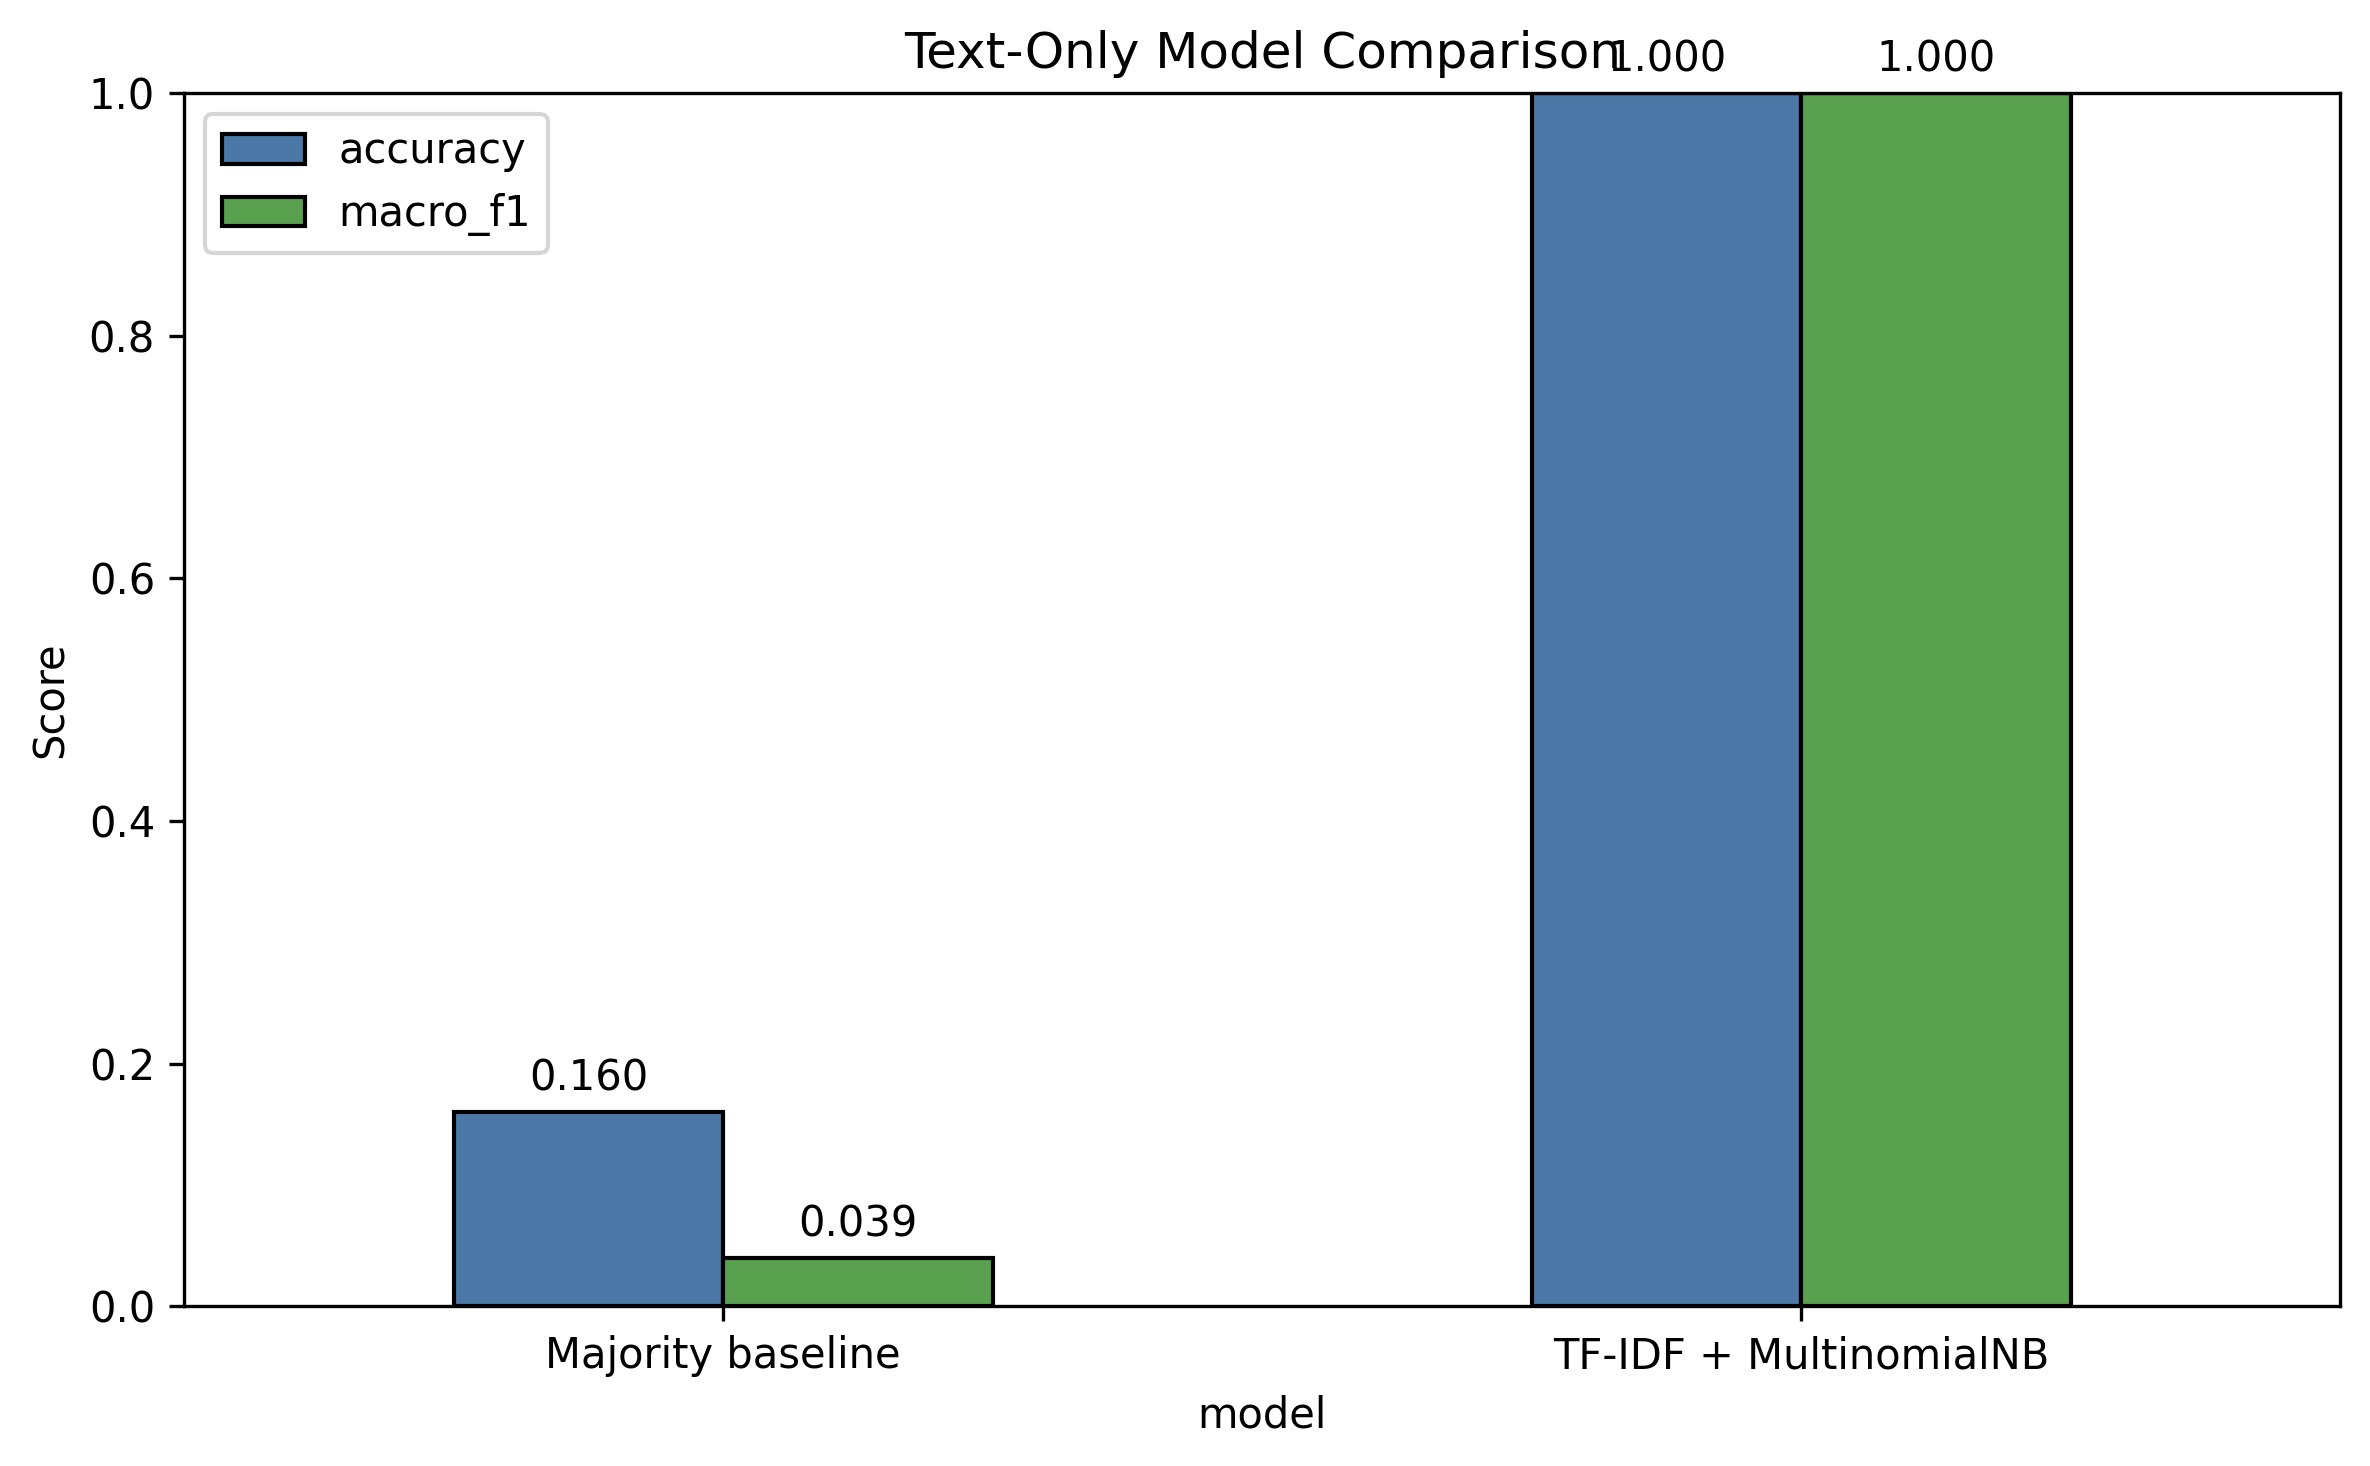

In [71]:
from IPython.display import Image, display

display(Image(filename=str(comparison_chart_path)))